In [1]:
import pandas as pd # для работы с датасетом
import seaborn as sns # для визуализации данных
from scipy import stats # для проведения статистических тестов

# для проведеня дисперсионного анализа
# anova model from formula
from statsmodels.formula.api import ols
# anova table from ols model
from statsmodels.stats.anova import anova_lm
# for qqplot
import statsmodels.api as sm
# tukey test
from statsmodels.stats.multicomp import pairwise_tukeyhsd
# correlation
from scipy.stats import pearsonr, spearmanr, kendalltau

<b>Контекст:</b>
Вы работаете в рекрутинговом агентстве по подбору персонала на позиции Data Science.

Данные представляют собой набор вакансий за 3 года, которые поступили в агентство. На их основе ответьте на следующие вопросы:

1. Что оказывает наиболее сильное влияние на зарплатную вилку в вакансии?
2. Как распределены позиции (грейды) сотрудников в компаниях разного размера и какие выводы можно сделать на основе полученного распределения?
3. В какую компанию выгоднее устраиваться сотруднику, грейд которого миддл или сеньор?

<b>В первую очередь</b> загружаем данные и выводим заголовки. Первая колнка индекс, используем её в качестве индекса в таблице.

In [3]:
data = pd.read_csv('ds_salaries.csv', index_col=0)
data.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,company_location,company_size
0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,DE,L
1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,JP,S
2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,GB,M
3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,HN,S
4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,US,L


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 607 entries, 0 to 606
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           607 non-null    int64 
 1   experience_level    607 non-null    object
 2   employment_type     607 non-null    object
 3   job_title           607 non-null    object
 4   salary              607 non-null    int64 
 5   salary_currency     607 non-null    object
 6   salary_in_usd       607 non-null    int64 
 7   employee_residence  607 non-null    object
 8   company_location    607 non-null    object
 9   company_size        607 non-null    object
dtypes: int64(3), object(7)
memory usage: 52.2+ KB


In [4]:
data.work_year.unique()

array([2020, 2021, 2022], dtype=int64)

В таблице три типа числовых данных: год работы, дискретная величина и зарплата - непрерывная.


In [5]:
data.experience_level.unique()

array(['MI', 'SE', 'JN', 'TL'], dtype=object)

In [6]:
data.company_size.unique()

array(['L', 'S', 'M'], dtype=object)

Опыт работы и размер компании - качественные, порядковые величины.

In [7]:
data.job_title.unique()

array(['Data Scientist', 'Machine Learning Scientist',
       'Big Data Engineer', 'Product Data Analyst',
       'Machine Learning Engineer', 'Data Analyst', 'Lead Data Scientist',
       'Business Data Analyst', 'Lead Data Engineer', 'Lead Data Analyst',
       'Data Engineer', 'Data Science Consultant', 'BI Data Analyst',
       'Director of Data Science', 'Research Scientist',
       'Machine Learning Manager', 'Data Engineering Manager',
       'Machine Learning Infrastructure Engineer', 'ML Engineer',
       'AI Scientist', 'Computer Vision Engineer',
       'Principal Data Scientist', 'Data Science Manager', 'Head of Data',
       '3D Computer Vision Researcher', 'Data Analytics Engineer',
       'Applied Data Scientist', 'Marketing Data Analyst',
       'Cloud Data Engineer', 'Financial Data Analyst',
       'Computer Vision Software Engineer',
       'Director of Data Engineering', 'Data Science Engineer',
       'Principal Data Engineer', 'Machine Learning Developer',
       

Наменование позиции - категориальная, качественная величина. В анализе её не учитываем.

<b>1. Что оказывает наиболее сильное влияние на зарплатную вилку в вакансии?</b>

Первым делом смотрим на распределение зарплат, если там есть выборсы и от них лучше избавиться.

<Axes: xlabel='salary_in_usd'>

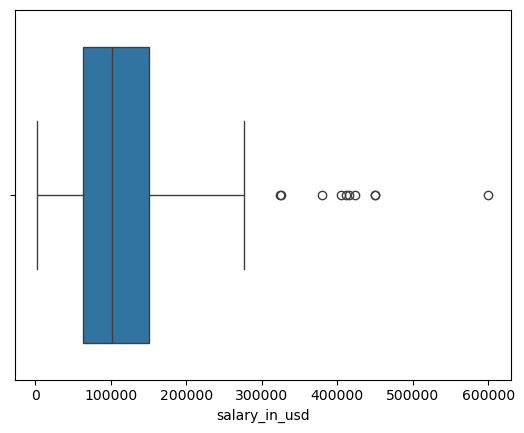

In [8]:
# воспользуемся графиком "ящик с усами" из библиотеки seaborn
sns.boxplot(data=data, x='salary_in_usd')

Видим, что у нас есть выбросы свыше 300_000. Избавимся от них.

In [9]:
data = data[data.salary_in_usd < 300_000]

<Axes: xlabel='salary_in_usd'>

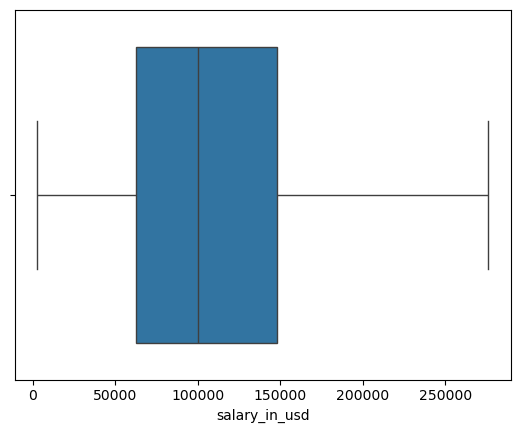

In [10]:
sns.boxplot(data=data, x='salary_in_usd')

Проведём корреляционный анализ между опытом работы и зарплатой. Воспользуемся методом Спирмена.

In [12]:
spearmanr(data.salary_in_usd, data.experience_level)

SignificanceResult(statistic=0.5579476468827914, pvalue=3.7950226626793873e-50)

Статистически значимый результат (p-value << 5%) сильной корреляции (55%). --> Зарплата сотрудника зависит от его грейда.

<Axes: xlabel='salary_in_usd', ylabel='Count'>

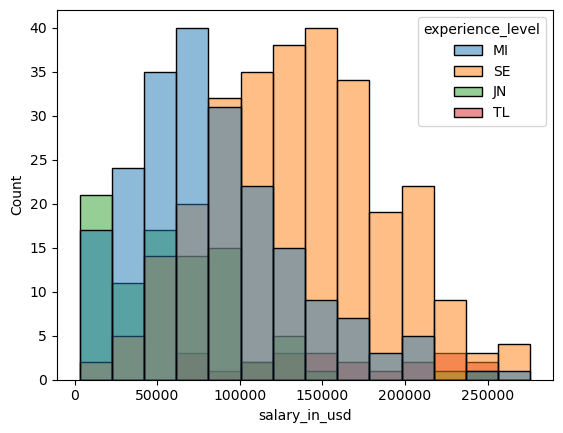

In [14]:
sns.histplot(data=data, x='salary_in_usd', hue='experience_level')

<b>2. Как распределены позиции (грейды) сотрудников в компаниях разного размера и какие выводы можно сделать на основе полученного распределения?</b>

<b>3. В какую компанию выгоднее устраиваться сотруднику, грейд которого миддл или сеньор?</b>